# Assignment 13 — Hadoop MapReduce WordCount in Java

## Topic Explanation

### What is Big Data?
**Big Data** refers to datasets too large to process on a single machine. The "3 V's":
- **Volume** — terabytes or petabytes of data
- **Velocity** — data arrives at high speed (streaming)
- **Variety** — structured (tables), semi-structured (JSON), unstructured (text, images, video)

Traditional databases choke on this. We need **distributed computing** — splitting data across many machines and processing in parallel.

### What is Hadoop?
**Apache Hadoop** is an open-source framework for distributed storage and processing of large datasets. Two core components:
- **HDFS (Hadoop Distributed File System)** — stores data across many machines with replication for fault tolerance
- **MapReduce** — programming model for parallel processing on top of HDFS

### What is MapReduce?
**MapReduce** is a programming model that breaks work into two phases:

#### 1. Map Phase
- Input is split into chunks (e.g., 64 MB blocks)
- Each chunk processed independently by a **Mapper** task running in parallel
- Mapper emits (key, value) pairs

#### 2. Shuffle Phase (handled automatically by Hadoop)
- Pairs with the same key are grouped together
- Sent to the same Reducer

#### 3. Reduce Phase
- Each Reducer receives a key and the list of all values for that key
- Reducer aggregates the values into a final result

### WordCount — The "Hello World" of MapReduce

| Phase | Input | Output |
|-------|-------|--------|
| **Map** | Text line: "Hadoop is big data" | (Hadoop, 1), (is, 1), (big, 1), (data, 1) |
| **Shuffle** | All emissions of all mappers | Grouped: (Hadoop, [1, 1]), (is, [1, 1]), ... |
| **Reduce** | (Hadoop, [1, 1]) | (Hadoop, 2) |

### Hadoop Java API — Key Classes

| Class | Purpose |
|-------|---------|
| `Mapper<Kin, Vin, Kout, Vout>` | Base class for map functions |
| `Reducer<Kin, Vin, Kout, Vout>` | Base class for reduce functions |
| `Text` | Hadoop's serializable string type |
| `IntWritable` | Hadoop's serializable integer type |
| `Job` | Configures and submits a MapReduce job |
| `FileInputFormat / FileOutputFormat` | Specifies HDFS input/output paths |
| `Context` | Used to write output from Map/Reduce |

### Why Hadoop's Own Types?
Standard Java types like `String` and `Integer` aren't efficient over a network. Hadoop provides **`Writable`** types (`Text`, `IntWritable`, `LongWritable`, `DoubleWritable`) optimized for serialization across machines.

## Step 1: Java Source Code — `WordCount.java`

The complete Java file with three classes:
1. **`TokenizerMapper`** — splits each line into words, emits `(word, 1)`
2. **`IntSumReducer`** — sums all `1`s for each word
3. **`main`** — driver code that configures and runs the job

In [1]:
# Display the Java source code (this cell just prints it; it's NOT executed Python).
java_code = '''
import java.io.IOException;
import java.util.StringTokenizer;

import org.apache.hadoop.conf.Configuration;
import org.apache.hadoop.fs.Path;
import org.apache.hadoop.io.IntWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Job;
import org.apache.hadoop.mapreduce.Mapper;
import org.apache.hadoop.mapreduce.Reducer;
import org.apache.hadoop.mapreduce.lib.input.FileInputFormat;
import org.apache.hadoop.mapreduce.lib.output.FileOutputFormat;

public class WordCount {

    /* =========================================================
       MAPPER
       Input  : (LineNumber, Text line)
       Output : (Word, 1) for every word in the line
       ========================================================= */
    public static class TokenizerMapper
            extends Mapper<Object, Text, Text, IntWritable> {

        // Reuse one IntWritable("1") for every emission - saves memory
        private final static IntWritable one = new IntWritable(1);
        private Text word = new Text();

        @Override
        public void map(Object key, Text value, Context context)
                throws IOException, InterruptedException {

            // Split the line into tokens (whitespace by default)
            StringTokenizer itr = new StringTokenizer(value.toString());

            while (itr.hasMoreTokens()) {
                // Lowercase + clean punctuation so "Hadoop" and "hadoop." count together
                String token = itr.nextToken().toLowerCase().replaceAll("[^a-zA-Z]", "");
                if (!token.isEmpty()) {
                    word.set(token);
                    context.write(word, one);   // emit (word, 1)
                }
            }
        }
    }

    /* =========================================================
       REDUCER
       Input  : (Word, [1, 1, 1, ...])  - all 1s for each word
       Output : (Word, totalCount)
       ========================================================= */
    public static class IntSumReducer
            extends Reducer<Text, IntWritable, Text, IntWritable> {

        private IntWritable result = new IntWritable();

        @Override
        public void reduce(Text key, Iterable<IntWritable> values, Context context)
                throws IOException, InterruptedException {

            int sum = 0;
            for (IntWritable val : values) {
                sum += val.get();           // accumulate all 1s
            }
            result.set(sum);
            context.write(key, result);     // emit (word, total_count)
        }
    }

    /* =========================================================
       DRIVER
       Configures and submits the job to Hadoop
       ========================================================= */
    public static void main(String[] args) throws Exception {
        // Sanity check
        if (args.length != 2) {
            System.err.println("Usage: WordCount <input path> <output path>");
            System.exit(-1);
        }

        // Standard Hadoop configuration object
        Configuration conf = new Configuration();
        Job job = Job.getInstance(conf, "word count");

        // Tell Hadoop which JAR contains our code
        job.setJarByClass(WordCount.class);

        // Wire up the Mapper/Combiner/Reducer
        job.setMapperClass(TokenizerMapper.class);
        job.setCombinerClass(IntSumReducer.class);   // local pre-aggregation
        job.setReducerClass(IntSumReducer.class);

        // Output type declaration
        job.setOutputKeyClass(Text.class);
        job.setOutputValueClass(IntWritable.class);

        // Input/output paths from command-line args
        FileInputFormat.addInputPath(job, new Path(args[0]));
        FileOutputFormat.setOutputPath(job, new Path(args[1]));

        // Submit and wait
        System.exit(job.waitForCompletion(true) ? 0 : 1);
    }
}
'''
print(java_code)


import java.io.IOException;
import java.util.StringTokenizer;

import org.apache.hadoop.conf.Configuration;
import org.apache.hadoop.fs.Path;
import org.apache.hadoop.io.IntWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Job;
import org.apache.hadoop.mapreduce.Mapper;
import org.apache.hadoop.mapreduce.Reducer;
import org.apache.hadoop.mapreduce.lib.input.FileInputFormat;
import org.apache.hadoop.mapreduce.lib.output.FileOutputFormat;

public class WordCount {

    /* =========================================================
       MAPPER
       Input  : (LineNumber, Text line)
       Output : (Word, 1) for every word in the line
       ========================================================= */
    public static class TokenizerMapper
            extends Mapper<Object, Text, Text, IntWritable> {

        // Reuse one IntWritable("1") for every emission - saves memory
        private final static IntWritable one = new IntWritable(1);
        private Text

## Step 2: Compilation and Run Commands

These are bash commands you run in a terminal — **they are not Python**. They're shown here for reference.

### 2.1 Set up environment

```bash
# Set Hadoop classpath
export HADOOP_CLASSPATH=$(hadoop classpath)
export JAVA_HOME=/usr/lib/jvm/default-java
```

### 2.2 Compile the Java file

```bash
# Compile WordCount.java into class files
mkdir wordcount_classes
javac -classpath ${HADOOP_CLASSPATH} -d wordcount_classes WordCount.java

# Bundle the classes into a JAR
jar -cvf wordcount.jar -C wordcount_classes/ .
```

### 2.3 Prepare input on HDFS

```bash
# Create an input directory on HDFS
hadoop fs -mkdir -p /input

# Upload your text file(s)
hadoop fs -put sample_text.txt /input/

# Verify
hadoop fs -ls /input
```

### 2.4 Run the MapReduce job

```bash
# Output directory must NOT exist beforehand
hadoop jar wordcount.jar WordCount /input /output
```

### 2.5 View the results

```bash
# List output files
hadoop fs -ls /output

# View the actual word counts
hadoop fs -cat /output/part-r-00000
```

The output looks like:
```
data    3
hadoop  4
is      2
mapreduce 3
the     5
...
```

## Step 3: Local Standalone Mode (No HDFS)

If you're running Hadoop in **standalone mode** (single machine, no HDFS), you can use local file paths instead of HDFS paths:

```bash
# Set Hadoop to local mode (default if HADOOP_CONF_DIR isn't set)
export HADOOP_CONF_DIR=

# Run with local paths
hadoop jar wordcount.jar WordCount input/sample_text.txt output

# View the result locally
cat output/part-r-00000
```

In **standalone mode**:
- No HDFS — uses local filesystem
- No YARN (resource manager) — runs in a single JVM
- No replication or distributed processing
- Useful for development and testing

In **pseudo-distributed mode**: Hadoop daemons run on a single machine, simulating a cluster — uses HDFS but on one node.

In **fully-distributed mode**: real cluster across many machines (production).

## Step 4: Python Simulation

To prove the MapReduce logic works **without needing Hadoop installed**, here's a Python simulation that follows the exact same Map → Shuffle → Reduce pattern.

In [2]:
# Sample text file (or read from disk if you have one)
sample_text = '''Hadoop is the Elephant King!
A yellow and elegant thing.
He never forgets to mind the rules.
Hadoop loves data and his MapReduce tools.
The framework processes big data efficiently.
MapReduce splits work into map and reduce tasks.
Hadoop and MapReduce work together perfectly.'''

# Write the text to a file so we have a real input file
with open('sample_text.txt', 'w') as f:
    f.write(sample_text)

print("Sample text saved to sample_text.txt")
print(f"Number of lines: {len(sample_text.split(chr(10)))}")

Sample text saved to sample_text.txt
Number of lines: 7


In [3]:
# ============== MAP PHASE ==============
# Each line is processed independently. Mapper emits (word, 1) for each word.

import re

def mapper(line):
    """Java equivalent: TokenizerMapper.map()"""
    pairs = []
    for token in line.split():
        # Same cleaning as Java code: lowercase + remove punctuation
        word = re.sub(r'[^a-zA-Z]', '', token).lower()
        if word:
            pairs.append((word, 1))
    return pairs

# Apply mapper to every line
with open('sample_text.txt') as f:
    text = f.read()

mapped = []
for line in text.split('\n'):
    mapped.extend(mapper(line))

print(f"Total emissions from Map phase: {len(mapped)}")
print("\nFirst 10 (word, 1) pairs:")
for pair in mapped[:10]:
    print(f"  {pair}")

Total emissions from Map phase: 44

First 10 (word, 1) pairs:
  ('hadoop', 1)
  ('is', 1)
  ('the', 1)
  ('elephant', 1)
  ('king', 1)
  ('a', 1)
  ('yellow', 1)
  ('and', 1)
  ('elegant', 1)
  ('thing', 1)


In [4]:
# ============== SHUFFLE PHASE ==============
# Group all emissions by key — all 1s for "hadoop" go together.

from collections import defaultdict

shuffled = defaultdict(list)
for key, value in mapped:
    shuffled[key].append(value)

print(f"Number of unique words after shuffle: {len(shuffled)}")
print("\nGrouped values for some words:")
for word in ['hadoop', 'mapreduce', 'and', 'the']:
    if word in shuffled:
        print(f"  ({word}, {shuffled[word]})")

Number of unique words after shuffle: 33

Grouped values for some words:
  (hadoop, [1, 1, 1])
  (mapreduce, [1, 1, 1])
  (and, [1, 1, 1, 1])
  (the, [1, 1, 1])


In [5]:
# ============== REDUCE PHASE ==============
# For each word, sum all the 1s.

def reducer(key, values):
    """Java equivalent: IntSumReducer.reduce()"""
    return (key, sum(values))

# Apply reducer to each group
results = [reducer(k, v) for k, v in shuffled.items()]

# Sort by count descending, then alphabetically
results.sort(key=lambda x: (-x[1], x[0]))

print("Final word counts (sorted by frequency):")
import pandas as pd
df = pd.DataFrame(results, columns=['Word', 'Count'])
df.head(20)

Final word counts (sorted by frequency):


,Word,Count
0,and,4
1,hadoop,3
2,mapreduce,3
3,the,3
4,data,2
5,work,2
6,a,1
7,big,1
8,efficiently,1
9,elegant,1


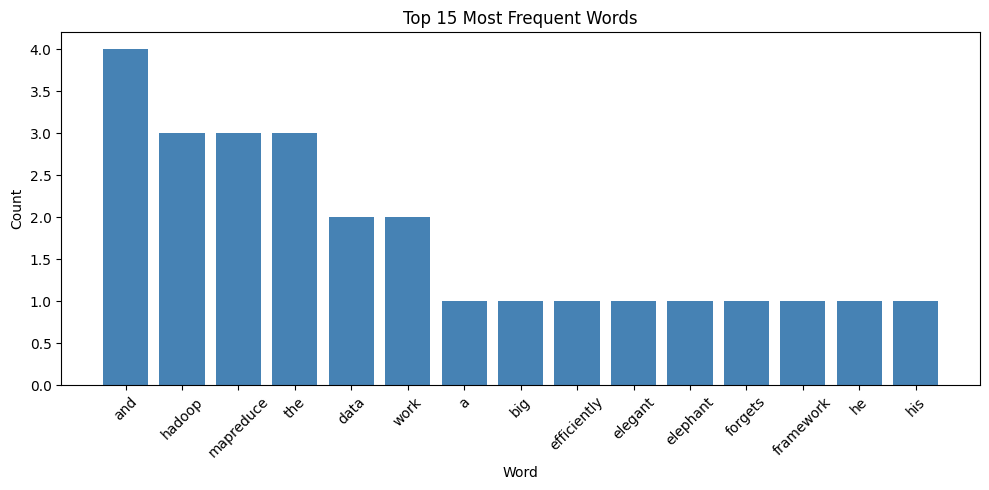

In [6]:
# Visualize the top 15 most frequent words
import matplotlib.pyplot as plt
%matplotlib inline

top15 = df.head(15)
plt.figure(figsize=(10, 5))
plt.bar(top15['Word'], top15['Count'], color='steelblue')
plt.title('Top 15 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

We implemented WordCount three ways:

1. **Java source code** (`WordCount.java`) using the Hadoop MapReduce API:
   - `TokenizerMapper` emits `(word, 1)` for every word
   - `IntSumReducer` sums up the 1s per word
   - The driver `main()` configures and submits the job

2. **Compilation and run commands** for both HDFS and local standalone modes.

3. **Python simulation** that follows the exact same Map → Shuffle → Reduce pattern, proving the logic works.

**Key MapReduce concepts demonstrated:**
- **Mapper** runs in parallel across data chunks, emits intermediate (key, value) pairs
- **Shuffle** groups pairs by key (handled automatically by Hadoop)
- **Reducer** aggregates all values for each key into a final answer
- **Combiner** is an optimization — runs the reducer logic on each mapper's local output to reduce network traffic

## Explanation of Everything Used

### Hadoop Java Classes Used

| Class | Purpose |
|-------|---------|
| `Configuration` | Holds Hadoop runtime settings |
| `Job` | Represents a MapReduce job; `getInstance()` creates one |
| `Mapper<Kin, Vin, Kout, Vout>` | Base class for map functions; `Kin/Vin` = input types, `Kout/Vout` = output types |
| `Reducer<Kin, Vin, Kout, Vout>` | Base class for reduce functions |
| `Text` | Hadoop's serializable equivalent of `String` |
| `IntWritable` | Hadoop's serializable equivalent of `int` |
| `Path` | Represents an HDFS or local file path |
| `FileInputFormat` | Configures input file paths for the job |
| `FileOutputFormat` | Configures the output directory for the job |
| `Context` | Object the Map/Reduce uses to emit output |

### Java Standard Library

| Class | Purpose |
|-------|---------|
| `StringTokenizer` | Splits a string by whitespace (or other delimiters) |
| `IOException` | Standard exception when I/O fails |
| `InterruptedException` | Thrown when a thread is interrupted |

### Compilation Commands Explained

| Command | Meaning |
|---------|---------|
| `hadoop classpath` | Prints all Hadoop JAR paths needed for compilation |
| `javac -classpath ... -d outdir File.java` | Compiles Java with classpath; `-d` sets output dir |
| `jar -cvf out.jar -C dir/ .` | Bundles compiled `.class` files into a JAR |
| `hadoop fs -mkdir`, `-put`, `-cat`, `-ls` | HDFS file operations |
| `hadoop jar X.jar Class arg1 arg2` | Runs a MapReduce job |

### Key Concepts

#### Why MapReduce?
- **Scalability** — process petabytes by adding more machines
- **Fault tolerance** — failed tasks are automatically re-run
- **Locality** — computation runs where the data already is
- **Simplicity** — programmer writes map/reduce, framework handles distribution

#### Why Hadoop's Writable Types?
Standard Java types aren't efficient for network transmission. Hadoop's `Writable` interface provides serialization optimized for the cluster.

#### What is the Combiner?
A "mini-reducer" that runs on each mapper's output before the shuffle. Reduces network traffic by combining values locally first. Often the same class as the reducer (as in our code).

Example without combiner: Mapper sends 1000 (`hadoop`, 1) pairs across the network.
With combiner: Mapper sends 1 (`hadoop`, 1000) pair across the network.

#### HDFS — Hadoop Distributed File System
Stores files across many machines:
- Files split into blocks (128 MB default)
- Each block replicated 3× for fault tolerance
- NameNode tracks block locations
- DataNodes store the actual blocks

#### Three Hadoop Modes
- **Standalone** — single JVM, local filesystem, no HDFS, no YARN. For testing.
- **Pseudo-distributed** — Hadoop daemons on one machine, uses HDFS, simulates a cluster
- **Fully-distributed** — real cluster across many machines (production)

## Viva Questions (with Answers)

### Conceptual

**Q1. What is Hadoop?**
An open-source framework for distributed storage and processing of large datasets across clusters of computers. Two core components: HDFS (storage) and MapReduce (processing).

**Q2. What is MapReduce?**
A programming model for parallel processing of large datasets in two phases: **Map** (process records in parallel and emit key-value pairs) and **Reduce** (aggregate values per key).

**Q3. What is HDFS?**
Hadoop Distributed File System. Stores files across many machines with replication (default 3×) for fault tolerance.

**Q4. What is Big Data?**
Datasets so large or complex that traditional tools can't process them. Characterized by 3 V's: Volume, Velocity, Variety.

### MapReduce Specifics

**Q5. What does the Mapper do?**
Processes input records (typically lines of text) and emits intermediate (key, value) pairs.

**Q6. What does the Reducer do?**
Receives a key and a list of all values for that key, and aggregates them into a final result.

**Q7. What is the Shuffle phase?**
Hadoop automatically sorts and groups the mapper output by key, then sends each key's values to the same reducer. The programmer doesn't write this — it's framework-managed.

**Q8. What is a Combiner?**
A mini-reducer that runs on each mapper's local output to reduce network traffic. Often the same class as the actual Reducer. Optional but improves performance.

**Q9. Why is MapReduce scalable?**
Map tasks run in parallel on independent data chunks. Adding more machines means more parallel mappers — linear speedup for many workloads.

**Q10. What's the lifecycle of a MapReduce job?**
1. Input split into chunks
2. Mappers run in parallel (one per chunk)
3. Shuffle groups pairs by key
4. Reducers run in parallel (one per key group)
5. Output written to HDFS

### Java Specifics

**Q11. Why does Hadoop use `Text` and `IntWritable` instead of `String` and `Integer`?**
Java's standard types aren't efficient for network serialization. Hadoop's `Writable` interface provides faster, more compact serialization.

**Q12. What does `context.write(key, value)` do?**
Emits the (key, value) pair to the next phase. In a Mapper, it goes to the shuffle. In a Reducer, it goes to the output file.

**Q13. What's the role of the `main` method?**
It's the **driver** — configures the job (mapper class, reducer class, input/output paths, types) and submits it to the cluster.

**Q14. What does `setJarByClass()` do?**
Tells Hadoop which JAR file contains the compiled code. Hadoop ships this JAR to every node in the cluster.

**Q15. Why is the output directory required to NOT exist before running?**
Hadoop deliberately fails if the output directory exists, to prevent accidentally overwriting previous results. Delete it first or use a new path.

### Operational

**Q16. What are Hadoop's three execution modes?**
- **Standalone** — single JVM, local filesystem (for development)
- **Pseudo-distributed** — daemons on one machine, uses HDFS
- **Fully-distributed** — real cluster across many machines

**Q17. How do you upload data to HDFS?**
Use `hadoop fs -put localfile /hdfs/path/`.

**Q18. How do you view MapReduce output?**
Use `hadoop fs -cat /output/part-r-00000`.

**Q19. What happens if a node fails during a MapReduce job?**
Hadoop automatically re-runs the failed task on another node, using the data that's still replicated elsewhere.

**Q20. What's the difference between MapReduce and Spark?**
- **MapReduce** writes intermediate results to disk between phases (slower, more reliable)
- **Spark** keeps data in memory (much faster, but needs more RAM)

Spark has largely replaced MapReduce in modern Big Data workflows but the MapReduce model remains foundational.